In [24]:
import pandas as pd

df = pd.read_csv("HousingData.csv")  


In [65]:
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.datasets import make_classification, make_regression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.metrics import accuracy_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
np.random.seed(0)
print("Missing value per column:")
print(df.isna().sum())

Missing value per column:
CRIM       20
ZN         20
INDUS      20
CHAS       20
NOX         0
RM          0
AGE        20
DIS         0
RAD         0
TAX         0
PTRATIO     0
B           0
LSTAT      20
MEDV        0
dtype: int64


In [43]:
features = ["RM", "TAX", "PTRATIO", "DIS", "NOX", "B"]
X = df[features] 
y = df["MEDV"]              
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [44]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)
print(f"Training samples: {X_train_scaled.shape[0]}, Test samples: {X_test_scaled.shape[0]}")

Training samples: 404, Test samples: 102


In [66]:
param_grid = {'n_neighbors': list(range(1, 31, 2)),
              'metric':['euclidean', 'manhattan']}
knn_reg= KNeighborsRegressor()
grid_reg = GridSearchCV(knn_reg, param_grid, cv=5,
                        scoring='neg_mean_squared_error')
grid_reg.fit(X_train_scaled, y_train)
best_k = grid_reg.best_params_['n_neighbors']
best_cv_rmse = np.sqrt(-grid_reg.best_score_)
print(f"Best k: {best_k}")
print(f"Best cross-validation RMSE: {best_cv_rmse:.3f}")

y_pred_cv= grid_reg.predict(X_test_scaled)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_cv))
print(f"Test RMSE with best k: {test_rmse:.3f}")
print(f"Best metric:{grid_reg.best_params_['metric']}")
best_reg_model=grid_reg.best_estimator_
r2=r2_score(y_test,y_pred_cv)
print("R^2 score:", r2)

Best k: 3
Best cross-validation RMSE: 4.998
Test RMSE with best k: 5.014
Best metric:manhattan
R^2 score: 0.6571343075365776


The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


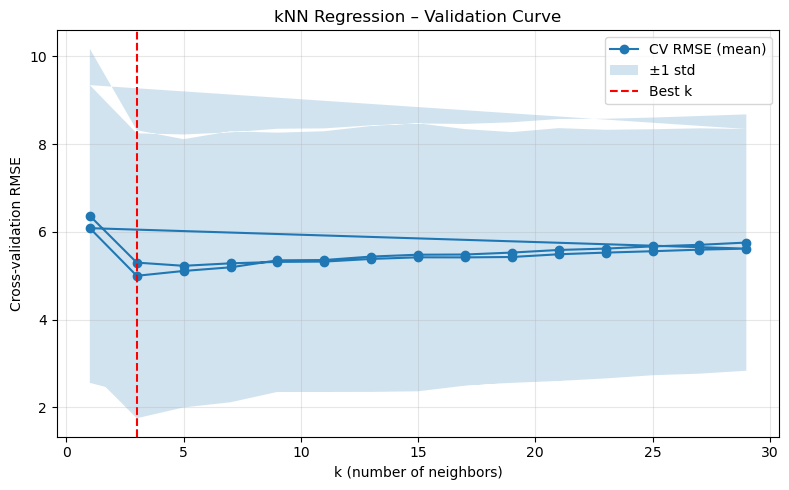

In [64]:
plt.figure(figsize=(8, 5))
results= grid_reg.cv_results_
k_vals = results['param_n_neighbors'].data.astype(int)
mean_neg_mse = results['mean_test_score']
mean_rmse = np.sqrt(-mean_neg_mse)   
std_neg_mse = results['std_test_score']
std_rmse = np.sqrt(std_neg_mse)      

plt.plot(k_vals, mean_rmse, 'o-', label='CV RMSE (mean)')
plt.fill_between(k_vals, mean_rmse - std_rmse, mean_rmse + std_rmse,
                 alpha=0.2, label='±1 std')
plt.axvline(best_k, color='red', linestyle='--', label='Best k')
plt.xlabel('k (number of neighbors)')
plt.ylabel('Cross-validation RMSE')
plt.title('kNN Regression – Validation Curve')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("knn_cv_regression.png", dpi=120);

In [46]:
joblib.dump(best_reg_model,'regression_model.pkl')

['regression_model.pkl']